In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
import os

# User input location

In [4]:
# Load the CSV file into a pandas DataFrame
csv_file = r"C:\Users\mj.j\OneDrive - PBA Systems Pte. Ltd\GitHub\Github\2024_10_17_13_25_27\Log_file_2D_expansion_X_axis_0.csv"
#csv_file = 'log_file.csv'  # Replace with your CSV file path
df = pd.read_csv(csv_file)

print(df.columns)


Index(['Run', 'image name', 'Y position', 'X position', 'Y comand position',
       'X comand position', 'Z comand position', 'axis_x_position_error',
       'axis_y_position_error', 'axis_z_position_error', ' pix_Y', 'pix_X',
       ' pix_R', ' temp0', ' temp1', ' temp2', 'temp3'],
      dtype='object')


In [4]:
# Convert the DataFrame to a NumPy array
data_array = df.to_numpy()

print (data_array.shape, data_array[0,13])

(40044, 17) 24.39


In [5]:
mean_radius=np.mean(data_array[:,12])
pixel_size = 250 / mean_radius
print(mean_radius,pixel_size)

568.8669557054909 0.43947006851533127


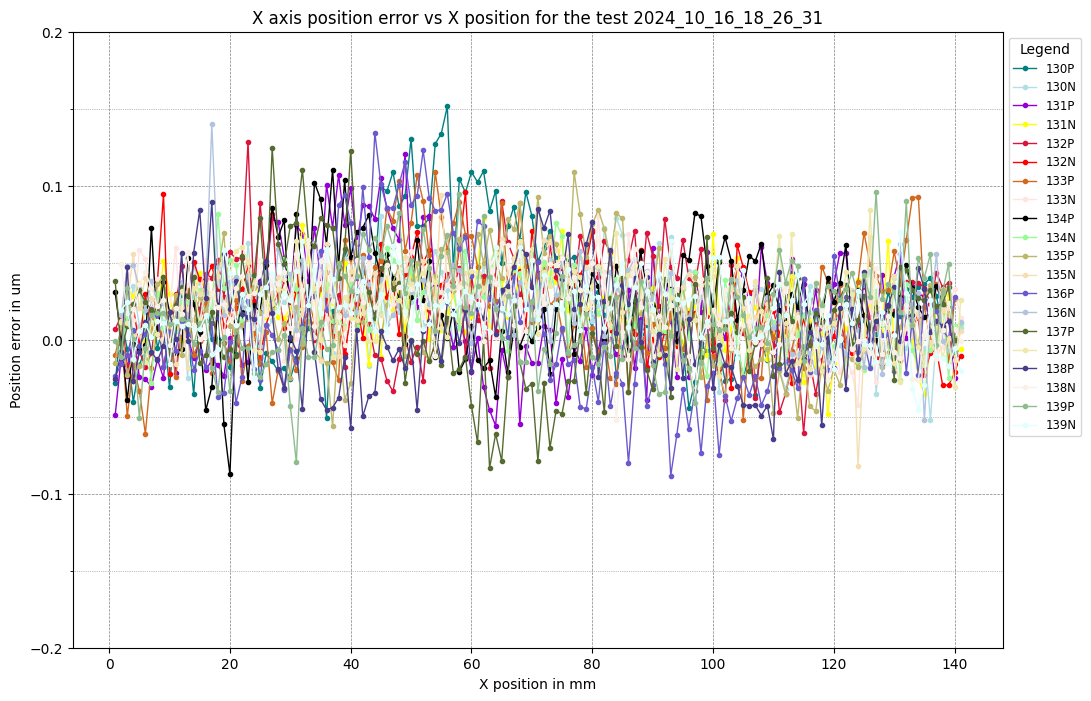

In [6]:
# Create a single figure for all plots
plt.figure(figsize=(12, 8))

# Define colors for P and N
colors_for_P = [
    'navy', 'darkred', 'forestgreen', 'darkorange', 'indigo',
    'maroon', 'purple', 'darkslategray', 'saddlebrown', 'mediumblue',
    'teal', 'darkviolet', 'crimson', 'chocolate', 'black', 'darkkhaki',
    'slateblue', 'darkolivegreen', 'darkslateblue', 'darkseagreen'
]

colors_for_N = [
    'lightblue', 'lightcoral', 'lightgreen', 'yellow', 'lightsalmon',
    'lightpink', 'lightgray', 'thistle', 'peachpuff', 'lavender',
    'powderblue', 'yellow', 'red', 'mistyrose', 'palegreen', 'wheat',
    'lightsteelblue', 'palegoldenrod', 'linen', 'lightcyan'
]

for run in range(130,140,1):
    cycle_image_count = 284    

    value_p_start = run * cycle_image_count + 1
    value_p_end = run * cycle_image_count + 141

    value_n_start = run * cycle_image_count + 143
    value_n_end = run * cycle_image_count + 283

    values_P = data_array[value_p_start:value_p_end] 
    values_N = data_array[value_n_start:value_n_end]

    # Extract X and Y values for P and N
    X_values_P = values_P[:, 3]  # Column 4 position index
    Y_values_P = (values_P[:, 11] - 1296) * -0.4403   # Column 11 position value # 10-1296 , 9-1024

    X_values_N = values_N[:, 3]  # Column 4 position index
    Y_values_N = (values_N[:, 11] - 1296) * -0.4403   # Column 11 position value

    # Plot the data for each run
    plt.plot(X_values_P, Y_values_P, marker='.', linestyle='-', color=colors_for_P[run-120], label=f'{str(run)}P', linewidth=1)
    plt.plot(X_values_N, Y_values_N, marker='.', linestyle='-', color=colors_for_N[run-120], label=f'{str(run)}N', linewidth=1)

# Add labels and title
plt.xlabel('X position in mm')
plt.ylabel('Position error in um')
plt.title('X axis position error vs X position for the test 2024_10_16_18_26_31')

# Set Y-axis limits
plt.ylim(-0.20, 0.20)  # Set Y-axis from -8 to +2

# Set major and minor ticks for the Y axis
ax = plt.gca()  # Get the current axes
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))  # Major ticks every 1 unit
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))  # Minor ticks every 0.2 unit

# Show the grid for both major and minor ticks
plt.grid(which='both', color='gray', linestyle='--', linewidth=0.5)  # Major grid
plt.grid(which='minor', linestyle=':', linewidth=0.5)  # Minor grid


# Show the legend outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small', title='Legend', title_fontsize='medium')

# Save the combined plot
file_name = f"aligmnet {run}"
plt.savefig("X_axis_position_error_for_0_141_72_72_2024_10_16_18_26_31_stepscombined_plot_with_subgrid.png", dpi=300, bbox_inches='tight')  # Use bbox_inches='tight' to adjust layout
plt.show()

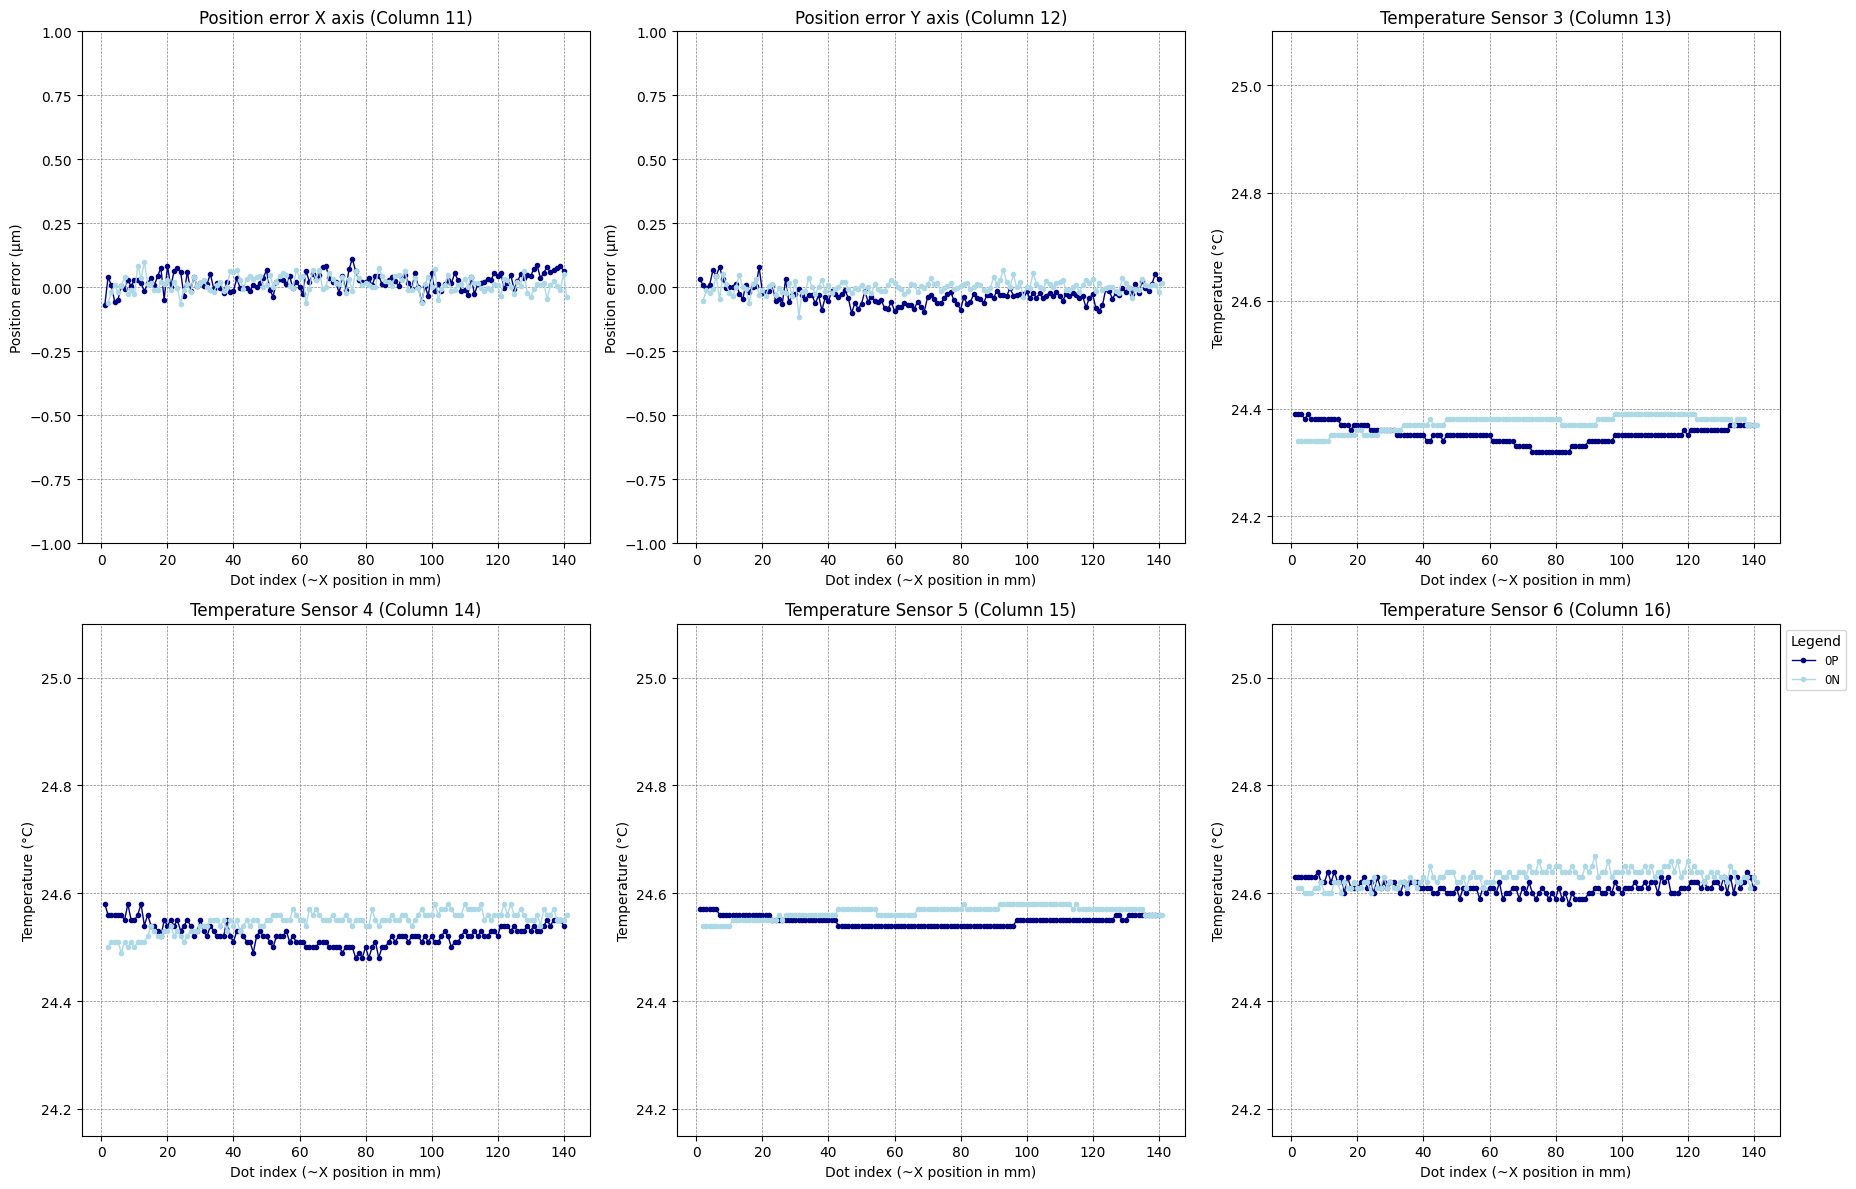

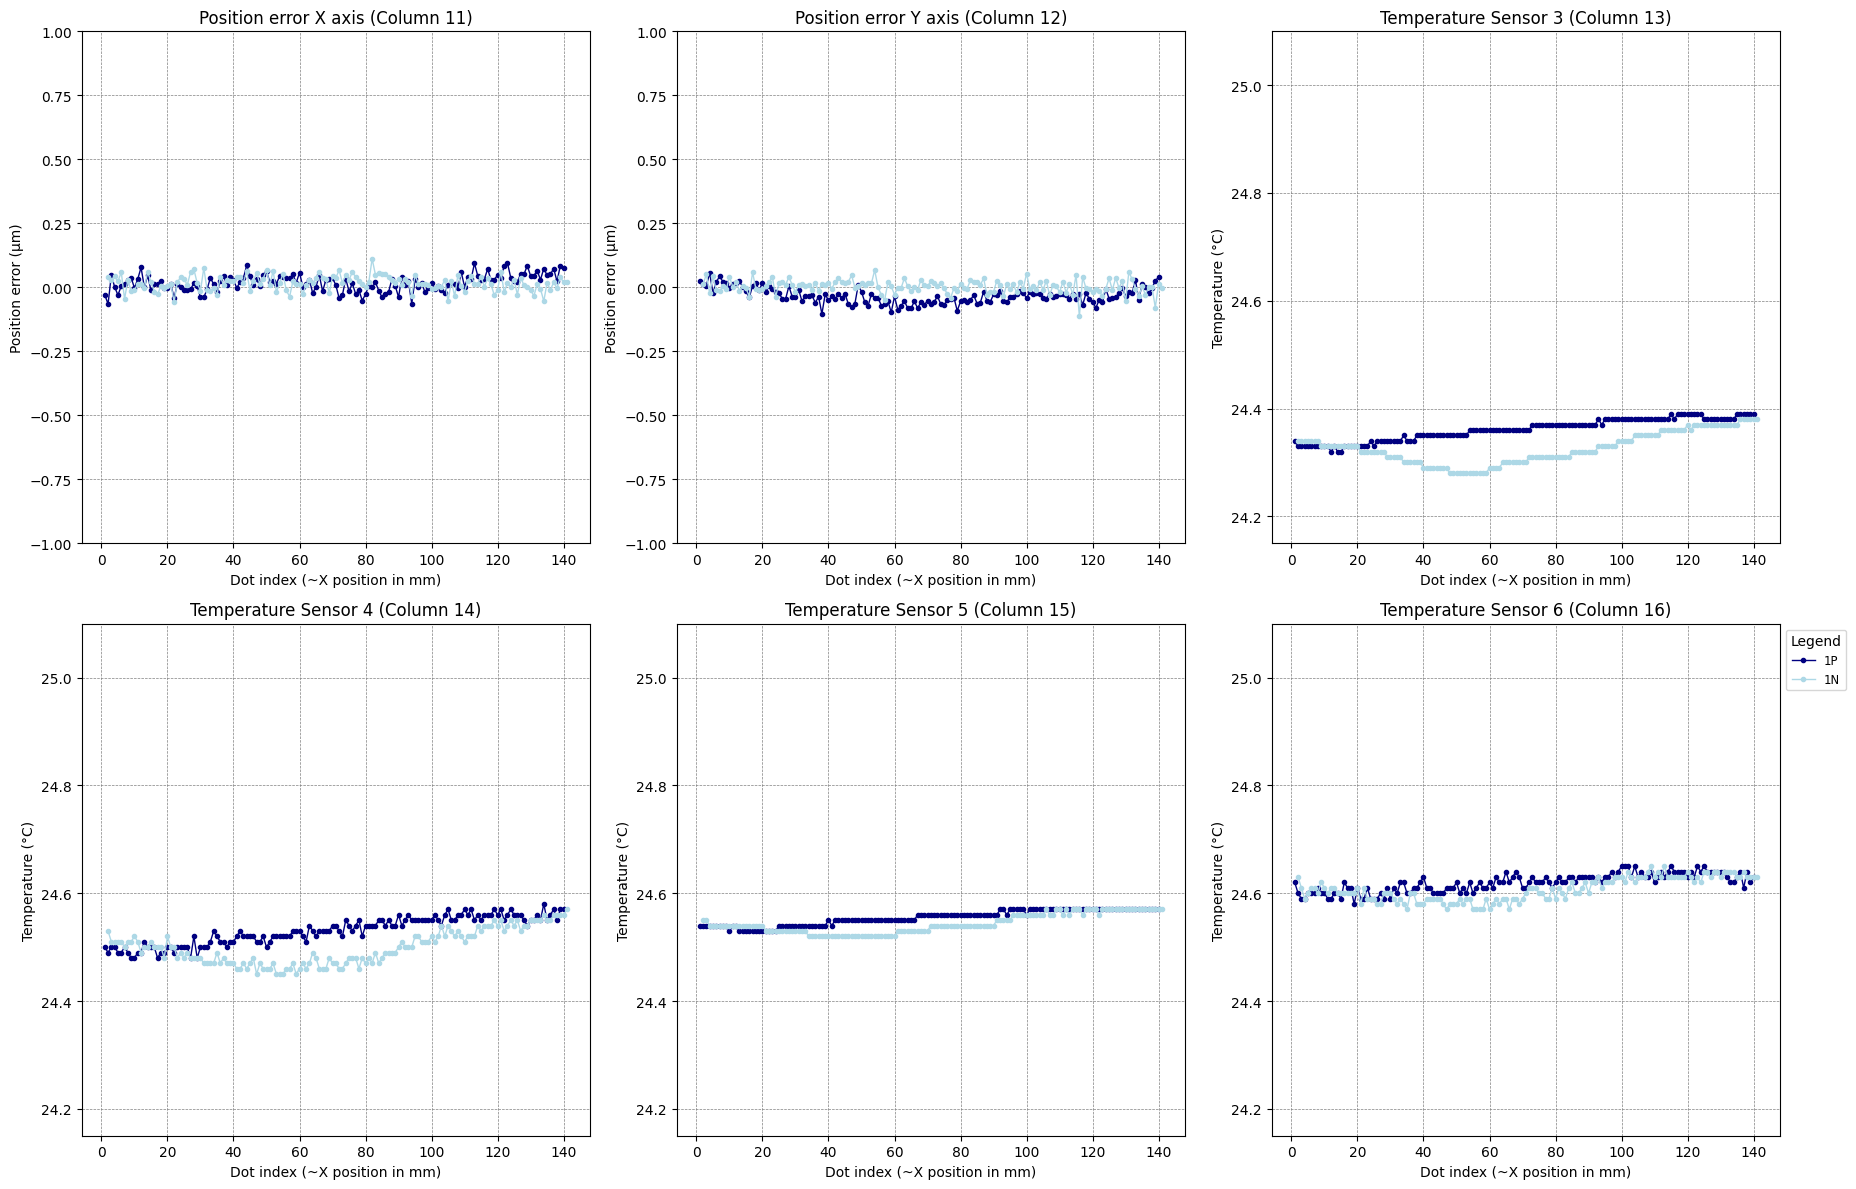

In [11]:
import matplotlib.pyplot as plt

# Loop over runs
for run in range(2):  # For each run, you will save a separate plot

    # Define the columns for temperature data and position error
    temperature_columns = [11, 12, 13, 14, 15, 16]

    # Titles for each subplot
    titles = [
        'Position error X axis (Column 11)',
        'Position error Y axis (Column 12)',
        'Temperature Sensor 3 (Column 13)',
        'Temperature Sensor 4 (Column 14)',
        'Temperature Sensor 5 (Column 15)',
        'Temperature Sensor 6 (Column 16)'
    ]

    # Define Y-axis limits for each plot
    y_limits = [
        (-1, 1),     # Position error X axis limits
        (-1, 1), # Position error Y axis limits
        (24.15, 25.10),  # Temperature Sensor 3 limits
        (24.15, 25.10),  # Temperature Sensor 4 limits
        (24.15, 25.10),  # Temperature Sensor 5 limits
        (24.15, 25.10)   # Temperature Sensor 6 limits
    ]

    cycle_image_count = 284    

    value_p_start = run * cycle_image_count + 1
    value_p_end = run * cycle_image_count + 141

    value_n_start = run * cycle_image_count + 143
    value_n_end = run * cycle_image_count + 283

    values_P = data_array[value_p_start:value_p_end] 
    values_N = data_array[value_n_start:value_n_end]


    # Create a new figure and axes for subplots for this run
    fig, axs = plt.subplots(2, 3, figsize=(18, 12))  # 2 rows, 3 columns
    axs = axs.flatten()  # Flatten for easier indexing in a loop

    # Loop through each subplot (temperature + position errors)
    for x in range(6):
        # Extract X and Y values for P and N for each subplot

        if x ==0:
            X_values_P = values_P[:, 3]         # Column 3: X position
            Y_values_P = (values_P[:, 11] - 1296) * -0.4403    # Column x+11: temperature or position error
            X_values_N = values_N[:, 3]         # Column 3: X position
            Y_values_N = (values_N[:, 11] - 1296) * -0.4403    # Column x+11: temperature or position error
        elif x == 1:
            X_values_P = values_P[:, 3]         # Column 3: X position
            Y_values_P = (values_P[:, 10]  - 1024) * -0.4403    # Column x+11: temperature or position error
            X_values_N = values_N[:, 3]         # Column 3: X position
            Y_values_N = (values_N[:, 10]  - 1024) * -0.4403    # Column x+11: temperature or position error
        else:
            X_values_P = values_P[:, 3]         # Column 3: X position
            Y_values_P = values_P[:, x + 11]    # Column x+11: temperature or position error
            X_values_N = values_N[:, 3]         # Column 3: X position
            Y_values_N = values_N[:, x + 11]    # Column x+11: temperature or position error

        # Plot the data in the respective subplot
        axs[x].plot(X_values_P, Y_values_P, marker='.', linestyle='-', color='navy', label=f'{str(run)}P', linewidth=1)
        axs[x].plot(X_values_N, Y_values_N, marker='.', linestyle='-', color='lightblue', label=f'{str(run)}N', linewidth=1)

        # Set labels and title for each subplot
        axs[x].set_xlabel('Dot index (~X position in mm)')
        if x == 0 or x == 1:
            axs[x].set_ylabel('Position error (µm)')
        else:
            axs[x].set_ylabel('Temperature (°C)')

        axs[x].set_title(titles[x])
        axs[x].set_ylim(y_limits[x])  # Set Y-axis limits

        # Set grid for each subplot
        axs[x].grid(True, color='gray', linestyle='--', linewidth=0.5)

    # Adjust layout for better spacing
    plt.tight_layout()

    # Add a single legend for the entire figure, outside the plot
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small', title='Legend', title_fontsize='medium')

    # Save the figure for the current run
    plt.savefig(f"Y_axis_position_{run+1}_full_variations.png", dpi=200, bbox_inches='tight')

    # Show the combined plot
    plt.show()

    # Close the figure to free up memory
    plt.close()

   
 

---


# Due to mechanical error the encoder values obtained from moving positive direction and moving negative deration can be different to study this

In [5]:
# Load the calculated referance location 
calculated_dot_file_location = r"C:\Users\mj.j\OneDrive - PBA Systems Pte. Ltd\GitHub\Github\2024_10_17_13_25_27\calculated_all_referance_locations.csv"

no_of_axis = 3
calculated_array_2d = np.loadtxt(calculated_dot_file_location, delimiter=',')
rows_in_file,column = calculated_array_2d.shape
calculated_calibration_data_table_row = rows_in_file//no_of_axis
calibration_data_table_column = column
calculated_position_np_array = calculated_array_2d.reshape(no_of_axis,calculated_calibration_data_table_row,calibration_data_table_column)
# X axis 
calculated_position_np_array[0][:][1]


array([ 95.21233 ,  94.211966,  93.211702,  92.211508,  91.211357,
        90.211147,  89.211125,  88.210986,  87.210847,  86.210707,
        85.210568,  84.210428,  83.210289,  82.21015 ,  81.21001 ,
        80.209871,  79.209731,  78.209592,  77.209453,  76.209313,
        75.209174,  74.209034,  73.208895,  72.208756,  71.208616,
        70.208477,  69.208337,  68.208198,  67.208059,  66.207919,
        65.20778 ,  64.20764 ,  63.207501,  62.207362,  61.207222,
        60.207083,  59.206943,  58.206804,  57.206665,  56.206525,
        55.206386,  54.206246,  53.206107,  52.205968,  51.205828,
        50.205689,  49.205549,  48.20541 ,  47.205271,  46.205131,
        45.204992,  44.204852,  43.204713,  42.204573,  41.204434,
        40.204295,  39.204155,  38.204016,  37.203876,  36.203737,
        35.203598,  34.203458,  33.203319,  32.203179,  31.20304 ,
        30.202901,  29.202761,  28.202622,  27.202482,  26.202343,
        25.202204,  24.202064,  23.201925,  22.201785,  21.201

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
import os

# Load the CSV file into a pandas DataFrame
csv_file = r"C:\Users\mj.j\OneDrive - PBA Systems Pte. Ltd\GitHub\Github\2024_10_17_13_25_27\Log_file_2D_expansion_X_axis_0.csv"
#csv_file = 'log_file.csv'  # Replace with your CSV file path
df = pd.read_csv(csv_file)

#print the header files
print(df.columns)

# Convert the DataFrame to a NumPy array
data_array = df.to_numpy()

#print the numpy array
print (data_array.shape, data_array[0,13])


mean_radius=np.mean(data_array[:,12])
pixel_size = 250 / mean_radius
print(mean_radius,pixel_size)

Index(['Run', 'image name', 'Y position', 'X position', 'Y comand position',
       'X comand position', 'Z comand position', 'axis_x_position_error',
       'axis_y_position_error', 'axis_z_position_error', ' pix_Y', 'pix_X',
       ' pix_R', ' temp0', ' temp1', ' temp2', 'temp3'],
      dtype='object')
(40044, 17) 24.39
568.8669557054909 0.43947006851533127


'Run' = 0,
'image name' = 1,
'Y position' = 2,
'X position' = 3,
'Y comand position' = 4,
'X comand position' = 5,
'Z comand position' = 6, 
'axis_x_position_error' = 7, 
'axis_y_position_error' = 8, 
'axis_z_position_error' = 9, 
'pix_Y' = 10, 
'pix_X' = 11, 
'pix_R' = 12, 
'temp0' = 13, 
'temp1' = 14, 
'temp2' = 15, 
'temp3' = 16

Just calculate the positon error in postive direction and negative direction motion error 

In [10]:
for i in range (0,142):
    for j in range (142,284):
        if data_array[i,3] == data_array[j,3]:
            print(calculated_position_np_array[0][1][i])                                #
            print(i,data_array[i,2],data_array[i,3],(data_array[i,11]-1296)*0.43947)    # 
            print(j,data_array[j,2], data_array[j,3],(data_array[j,11]-1296)*0.43947)   # 
            print(data_array[i,2],data_array[i,3],data_array[j,2],data_array[j,3],data_array[i,4],data_array[j,4],1000*(data_array[i,4] - data_array[j,4]))     # 
            print("---")



94.211966
1 1 1 0.07015238787630669
283 1 1 0.016307647697847635
1 1 1 1 94.21289274157628 94.21265778619671 0.23495537956819135
---
93.211702
2 1 2 -0.039701155617904334
282 1 2 0.06104386656135135
1 2 1 2 93.2125686739194 93.2123389558442 0.22971807520377752
---
92.211508
3 1 3 -0.007884309500603037
281 1 3 0.01778211438552889
1 3 1 3 92.21244659170316 92.21215403530408 0.2925563990743285
---
91.211357
4 1 4 0.05624915456347251
280 1 4 -0.007341921124916594
1 4 1 4 91.21226707901609 91.21189884515184 0.3682338642505556
---
90.211147
5 1 5 0.04836220975882176
279 1 5 0.017237191470863344
1 5 1 5 90.21191891060504 90.21153240344462 0.3865071604138848
---
89.211125
6 1 6 -0.004929667991915287
278 1 6 -0.0033173950809128453
1 6 1 6 89.21150898915631 89.21113949213449 0.36949702182198507
---
88.210986
7 1 7 0.0065552114147828236
277 1 7 -0.03858017785316699
1 7 1 7 88.21122404964514 88.21081253146717 0.4115181779695831
---
87.210847
8 1 8 -0.027349847290390954
276 1 8 0.025965654347140908

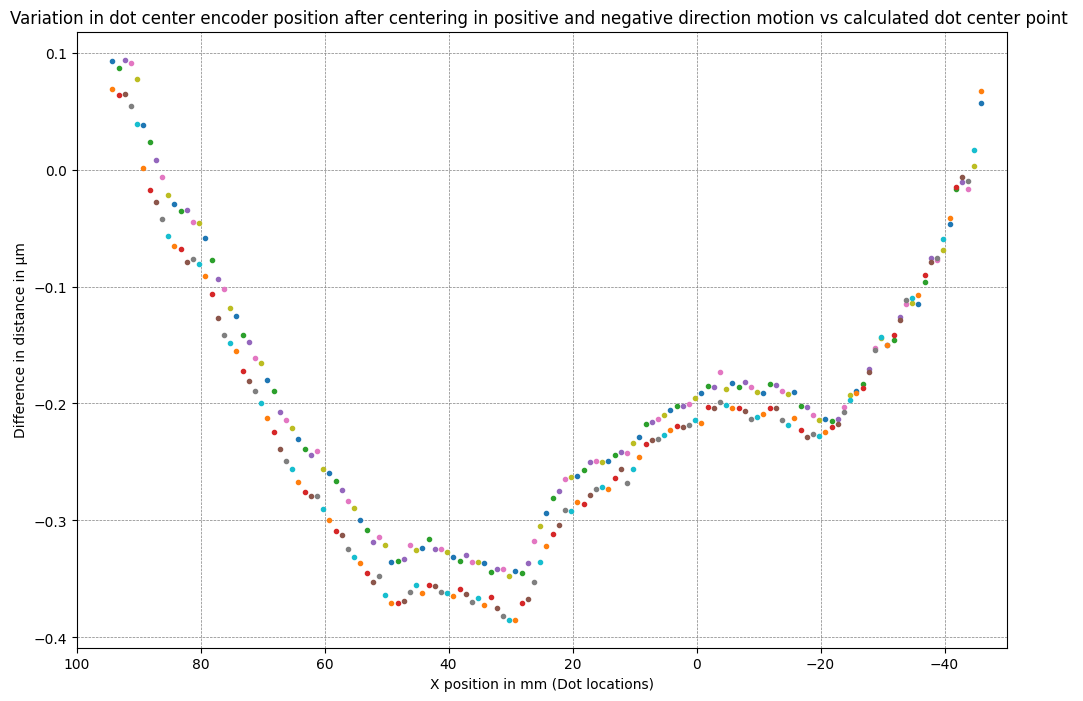

In [19]:
import matplotlib.pyplot as plt  # Import for plotting

# Assuming your data arrays are already defined

row_n = 1
for row_n in range (1,2,1):
    plt.figure(figsize=(12, 8))  # Set figure size
    for i in range(0, 142):
        for j in range(142, 284):
            if data_array[i, 3] == data_array[j, 3]:  # Check if specific values match
                # Plot points based on matching values
                
                plt.plot(calculated_position_np_array[0][row_n][i], (data_array[i,4] - calculated_position_np_array[0][row_n][i])*100, marker='.')  # Plot with marker
                plt.plot(calculated_position_np_array[0][row_n][i], (data_array[j,4] - calculated_position_np_array[0][row_n][i])*100, marker='.')  # Plot with marker

    # Add labels and title
    plt.xlabel("X position in mm (Dot locations)")
    plt.ylabel("Difference in distance in μm")
    plt.title("Variation in dot center encoder position after centering in positive and negative direction motion vs calculated dot center point ")
    # Set X-axis limits
    plt.xlim(+100, -50)  # Desired range for X-axis
    #plt.ylim(-0.5,35)

    plt.grid(which='both', color='gray', linestyle='--', linewidth=0.5)  # Major grid
    plt.grid(which='minor', linestyle=':', linewidth=0.5)  # Minor grid

    file_name = f"variation_plot_row_zoom_{row_n}"
    plt.savefig(file_name)
    #
    plt.show()


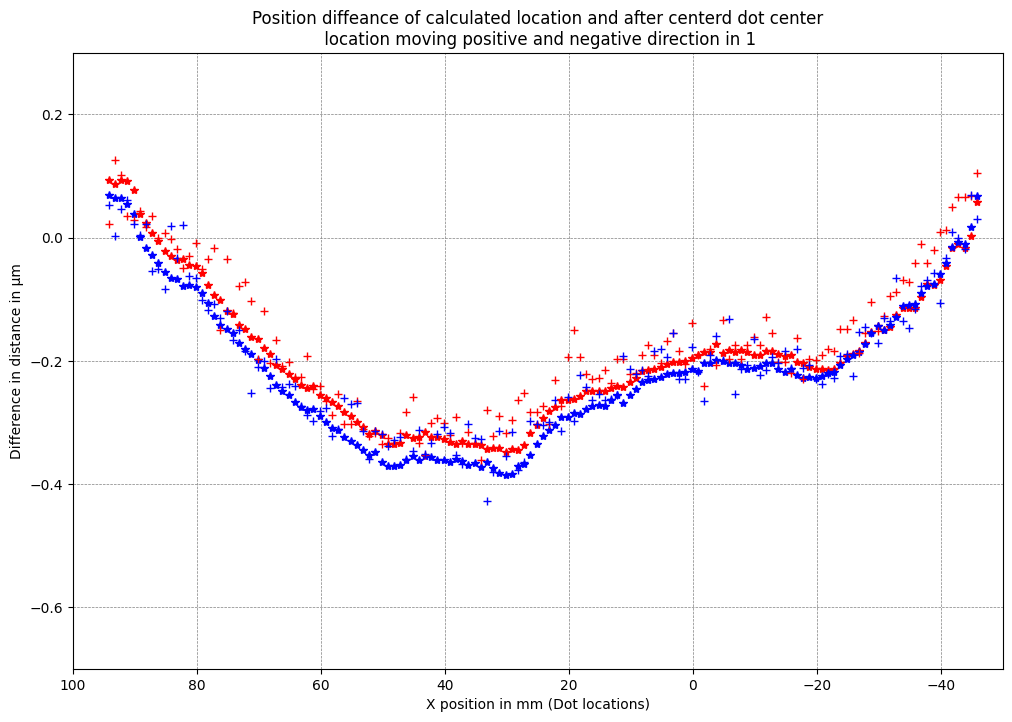

In [74]:
import matplotlib.pyplot as plt  # Import for plotting

# Assuming your data arrays are already defined
row_n = 0

for row_n in range (0,1,1):
    plt.figure(figsize=(12, 8))  # Set figure size
    for i in range(0, 142):
        for j in range(142, 284):
            if data_array[i, 3] == data_array[j, 3]:  # Check if specific values match
                # Plot points based on matching values
                #print(i,j)
                plt.plot(calculated_position_np_array[0][row_n+1][i], ((data_array[i+(284*row_n),4] - calculated_position_np_array[0][row_n+1][i])*100), marker='*',color='r')  # Plot with marker
                plt.plot(calculated_position_np_array[0][row_n+1][i], ((data_array[j+(284*row_n),4] - calculated_position_np_array[0][row_n+1][i])*100), marker='*',color = 'b')  # Plot with marker
                plt.plot(calculated_position_np_array[0][row_n+1][i], ((data_array[i+(284*row_n),4] - calculated_position_np_array[0][row_n+1][i])*100 - (data_array[i+(284*row_n),11]-1296)*0.43947), marker='+',color = 'r')  # Plot with marker
                plt.plot(calculated_position_np_array[0][row_n+1][i], ((data_array[j+(284*row_n),4] - calculated_position_np_array[0][row_n+1][i])*100 - (data_array[j+(284*row_n),11]-1296)*0.43947), marker='+',color = 'b')  # Plot with marker
                #plt.plot(calculated_position_np_array[0][row_n+1][i], ((data_array[i+(284*row_n),11]-1296)*0.43947), marker='.',color = 'r')  # Plot with marker
                #plt.plot(calculated_position_np_array[0][row_n+1][i], ((data_array[j+(284*row_n),11]-1296)*0.43947), marker='+',color = 'b')  # Plot with marker

    # Add labels and title
    plt.xlabel("X position in mm (Dot locations)")
    plt.ylabel("Difference in distance in μm")
    plt.title(f"Position diffeance of calculated location and after centerd dot center\n location moving positive and negative direction in {row_n+1}")
    
    # Set X-axis limits
    plt.xlim(+100, -50)  # Desired range for X-axis
    plt.ylim(-0.7,0.3)

    plt.grid(which='both', color='gray', linestyle='--', linewidth=0.5)  # Major grid
    plt.grid(which='minor', linestyle=':', linewidth=0.5)  # Minor grid

    file_name = f"Positon_error_moving_positive_and negative{row_n}"
    plt.savefig(file_name)
    
    # 
    plt.show()

